# Health Analytics (COMS5027A/FAMH4004A) 2026
# Lab 3 - Explanatory Linear Regression

## Instructions
* Run all the code cells in chronological order.
* Put your names and student numbers in the indicated cell in the exact indicated format.
* You cannot use additional libraries to the ones imported already for you.
* Your answers must be placed in the indicated answer code cells and must follow the requested format exactly.
* Code cells containing the comment `# STUDENT ANSWER` are answer code cells.
* Do not delete the answer code cells and recreate them as they have custom metadata used by the automarker. If you accidentally delete one, you must redownload the notebook.
* Answers must be computed programmatically. Computing by hand and simply setting the variable to that value will lead to a mark of zero since these will not be valid on the private test cases.

## Imports

In [1]:
# RUN THIS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
sns.set_theme()

## Student Details
Populate `student_names` and `student_numbers` with the full names and student numbers of each group member in the same order.

In [ ]:
student_names = ["Odwa Yamile"]  # Provide the FULL name of each group member as it appears on Moodle
student_numbers = ["2593714"]  # Provide the student number of each group member in the same order as student names. Ensure the student numbers are represented as strings

assert len(student_names) == len(student_numbers), "All student names must have an associated student number and vice-versa"
assert np.all([type(x) == str for x in student_numbers]), "All student numbers must be represented as strings"

## Public Test Cases
The 'public test cases' are used for you to check your answers, and sometimes act as a heuristic for if your answer is correct or not. Your answers will be marked by hand and/or programmatically using hidden test cases.

# Clinical Context & The Health Question

### Health Question: To what extent does a health district’s initial immunisation access explain its capacity to retain children for follow-up care across South Africa's districts?

**Variable Definitions:**
*   **Feature Variable ($X$):** *Immunisation under 1 year coverage* evaluates the overall efficacy of early childhood vaccination services, indicating access. It measures the percentage of infants under 12 months who successfully complete their full primary course of immunisations(vaccinations). This variable is represented by the column `immunised`.
*   **Target Variable ($Y$):** *Measles 2nd dose coverage* measures the healthcare system's capacity to provide a follow-up dose, indicating its utilisation rate. It tracks the proportion of children at 1 year of age (12 months) who receive their second follow-up measles dose. This variable is represented by the column `measles_2nd_dose`.

**Dataset Notes:** The dataset was extracted from a dataset from the District Health Barometer (see [here](https://www.hst.org.za/publications?pub=dhb)). It represents the time period 2024-2025. `geo_area` corresponds to districts and `geo_prov` corresponds to provinces.

# Load Data

The data is loaded for you below into a pandas DataFrame named `df`.

In [2]:
# RUN THIS & DO NOT MODIFY
df = pd.read_csv("https://raw.githubusercontent.com/SimonRosen173/health-analytics-26-data/refs/heads/main/labs/week_4/DHB_2024_child_immunisation.csv")
df.head()

,geo_area,geo_prov,immunised,measles_2nd_dose
0,A Nzo DM: DC44,EC,54.8,55.4
1,Amathole DM: DC12,EC,54.7,54.8
2,Buffalo City MM: BUF,EC,65.1,64.8
3,C Hani DM: DC13,EC,66.3,69.5
4,Joe Gqabi DM: DC14,EC,49.0,47.3


# 1) Checking Linearity

Before fitting a linear model, you must visually confirm that the relationship between primary vaccine access (`immunised`) and follow-up utilisation (`measles_2nd_dose`) satisfies the assumption of linearity.

#### Question 1
Generate a scatter plot using Seaborn to visually inspect the linearity between `immunised` (x-axis) and `measles_2nd_dose` (y-axis). I.e. inspect if a straight line can be drawn through the data.

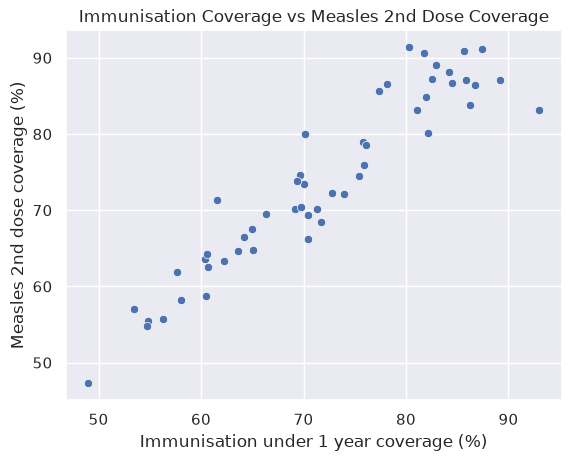

In [3]:
# STUDENT ANSWER
# TODO
sns.scatterplot(data=df, x="immunised", y="measles_2nd_dose")
plt.xlabel("Immunisation under 1 year coverage (%)")
plt.ylabel("Measles 2nd dose coverage (%)")
plt.title("Immunisation Coverage vs Measles 2nd Dose Coverage")
plt.show()

# 2) Model Training & Parameter Extraction

We will now build an explanatory linear regression model to quantify the systemic retention rate of the immunisation pipeline - i.e. how many infants vaccinated in their first year return for follow up vaccines. This "white box" model provides high transparency and interpretability. The model mathematically takes the form:

$$\text{Measles2nd}_{pred}=w_0+w_1\times\text{ImmunisationUnder1}$$

#### Question 2
Instantiate a `LinearRegression` model. Format your feature variable (`immunised`) as a DataFrame `X`, and your target variable (`measles_2nd_dose`) as a Series `y`. Fit the model to the data.

Extract the trained weights. Assign the intercept (`intercept_`) to the variable `model_intercept` and the slope coefficient (`coef_`) to the variable `retention_weight`.

In [4]:
# STUDENT ANSWER
X = df[["immunised"]]
y = df["measles_2nd_dose"]

model = LinearRegression()
model.fit(X, y)


model_intercept = model.intercept_
retention_weight = model.coef_

print(f"Intercept: {model_intercept}")
print(f"Retention Weight: {retention_weight}")

Intercept: 1.9428297798999807
Retention Weight: [1.00026032]


**Public Test Case**

In [5]:
# RUN THIS & DO NOT MODIFY
if np.isclose(retention_weight, 1.00026, atol=1e-4) and np.isclose(model_intercept, 1.9428, atol=1e-4):
    print("Answer for Q2 is likely correct.")
else:
    print("Answer for Q2 is incorrect.")

Answer for Q2 is likely correct.


# 3) Programmatic Prediction

#### Question 3
The Department of Health has set targets for three hypothetical districts to achieve exactly 70%, 80%, and 90% primary immunisation coverage under 1 year. Using your trained model, use the `predict` method to programmatically calculate the expected 2nd dose coverage for these specific inputs.

In [6]:
# STUDENT ANSWER
# Hint: ensure your data structure for new_districts is 2D - e.g. a Pandas DataFrame or a 2D numpy array 
new_districts = pd.DataFrame({"immunised": [70, 80, 90]})
predicted_coverage = model.predict(new_districts)

print(f"Predicted Coverage: {predicted_coverage}")

Predicted Coverage: [71.96105187 81.96365503 91.96625818]


**Public Test Case**

In [7]:
# RUN THIS & DO NOT MODIFY
expected_preds = np.array([71.961, 81.963, 91.966])
if np.allclose(predicted_coverage.flatten(), expected_preds, atol=1e-2):
    print("Answer for Q3 is likely correct.")
else:
    print("Answer for Q3 is incorrect.")

Answer for Q3 is likely correct.


# 4) Model Evaluation

To quantify the "goodness of fit", we compute the Mean Squared Error (MSE), which represents the cumulative error based on the distance between the true operational data and our model's predictions.

#### Question 4
Generate predictions for the entire original `X` dataset. Then, use `scikit-learn` to calculate the MSE comparing the true `y` labels to your predictions. Assign this to `model_mse`.

In [8]:
# STUDENT ANSWER
y_pred_all = model.predict(X)
model_mse = mean_squared_error(y, y_pred_all)

print(f"MSE: {model_mse}")

MSE: 14.904666704386095


**Public Test Case**

In [9]:
# RUN THIS & DO NOT MODIFY
if np.isclose(model_mse, 14.904, atol=1e-3):
    print("Answer for Q4 is likely correct.")
else:
    print("Answer for Q4 is incorrect.")

Answer for Q4 is likely correct.


# 5) Answering the Health Question

#### Question 5
Based off your results above and the provided clinical context provide a short answer to the health question. Hint: focus on the value of `retention_weight`.

*Answer in the Markdown cell below.*

ANSWER GOES HERE - Double click this cell to edit

Our model indicates that a district's success in providing children with their second measles dose is closely linked to how effectively it administers first-year vaccines. The retention_weight was calculated to be nearly 1.00, which suggests that for every 1% rise in first-year immunization coverage, the follow-up (2nd dose) coverage increases by about the same percentage approximately 1%. So basically districts don't actually lose children between the first and second doses if a district excels at reaching children early, it continues to excel at bringing them back for the follow-up. Therefore, a district's initial immunization access largely accounts for its follow-up care capacity, indicating that the main issue to address is increasing the number of children vaccinated initially, rather than a separate follow-up problem.

# END